In [16]:
from datasets import load_dataset
import re
from IPython.display import Image, display
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alonso\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
repo_id = "astroza/chilean-humor-raw-transcripts"
ds = load_dataset(repo_id, "segments", split="train")
segments = ds["text"]

ONLY_NUMERIC_RE = re.compile(r"^[\s0-9,.;:/+\-()\[\]{}]+$")
LETTER_RE = re.compile(r"[A-Za-zÁÉÍÓÚáéíóúÑñÜü]")

def is_numeric_noise(text: str) -> bool:
    if not text:
        return False
    t = text.strip()
    if not t:
        return False
    if LETTER_RE.search(t):
        return False
    return bool(ONLY_NUMERIC_RE.fullmatch(t))

new_ds = ds.filter(lambda x: not is_numeric_noise(x["text"]))
segments = new_ds["text"]

print(f"Total: {len(segments)} segments")

Total: 4591 segments


In [6]:

spanish_stopwords = stopwords.words("spanish")

vectorizer_model = CountVectorizer(stop_words=spanish_stopwords,
                                   min_df=2,
                                   ngram_range=(1, 2),
                                   token_pattern = r"(?ui)(?:^|[^\wáéíóúñü])([a-záéíóúñü][\wáéíóúñü]+)")

In [10]:
topic_model = BERTopic(language="multilingual",
                       vectorizer_model=vectorizer_model,
                       calculate_probabilities=True,
                       verbose=True)

topics, probs = topic_model.fit_transform(segments)

2026-02-10 10:45:36,081 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/144 [00:00<?, ?it/s]

2026-02-10 10:46:47,484 - BERTopic - Embedding - Completed ✓
2026-02-10 10:46:47,485 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-10 10:46:54,428 - BERTopic - Dimensionality - Completed ✓
2026-02-10 10:46:54,429 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-10 10:46:54,973 - BERTopic - Cluster - Completed ✓
2026-02-10 10:46:54,977 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-10 10:46:55,901 - BERTopic - Representation - Completed ✓


In [11]:
freq = topic_model.get_topic_info(); freq.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2544,-1_gracias_ahí_huevón_si,"[gracias, ahí, huevón, si, así, voy, ah, cómo,...","[Amigo mío, usted sabe, usted ya los vio, está..."
1,0,141,0_mamá_papá_hijo_hijos,"[mamá, papá, hijo, hijos, hija, ahí, casa, así...","[que sé que hoy día es una noche de jóvenes, p..."
2,1,128,1_chile_país_huevón_chileno,"[chile, país, huevón, chileno, así, chilenos, ...",[estos dos que son huevones. Me tienen hasta a...
3,2,124,2_huevón_ahí_huevada_dije,"[huevón, ahí, huevada, dije, así, si, huevona,...","[lamentablemente no es así, la huevona. Porque..."
4,3,120,3_doctor_dijo_dice_señora,"[doctor, dijo, dice, señora, ahí, médico, mamá...","[Doctor le dice, ""Mire, su señora veo que le f..."
5,4,119,4_dijo_dije_dice_si,"[dijo, dije, dice, si, así, ahí, señora, oye, ...","[en Viña, 2007. Cuatro amigos en una esquina, ..."
6,5,90,5_canción_mosca_mosca mosca_música,"[canción, mosca, mosca mosca, música, canción ...","[Con una canción maravillosa que dice, ""Las em..."
7,6,79,6_presidente_huevón_políticos_país,"[presidente, huevón, políticos, país, ser, pol...","[Yo tengo una teoría, yo tengo una teoría. Mi ..."
8,7,74,7_quinta_vergara_quinta vergara_gracias,"[quinta, vergara, quinta vergara, gracias, muc...","[Que sigo siendo aquel, el mismo. Muchas graci..."
9,8,74,8_almas_amor_amas_vida,"[almas, amor, amas, vida, dio, quiero, alma, n...",[Y todo me dio el amor. Y todo me dio el amor....


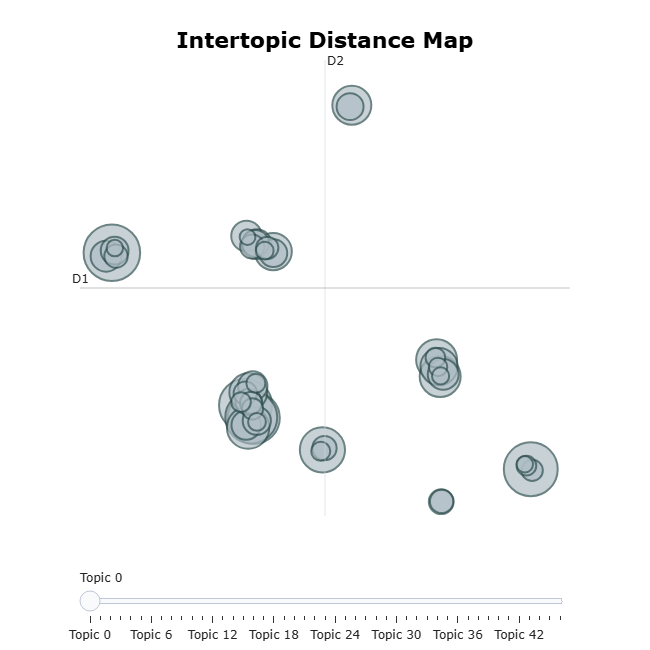

In [17]:
fig = topic_model.visualize_topics();
fig.write_image("topics.png")

display(Image(filename="topics.png"))

In [13]:
dates = new_ds["date"]


decades = [(int(d[:4]) // 10) * 10 for d in dates]

topics_over_time = topic_model.topics_over_time(
    docs=segments,
    timestamps=decades,
    global_tuning=True,
    evolution_tuning=True,
)

6it [00:01,  3.50it/s]


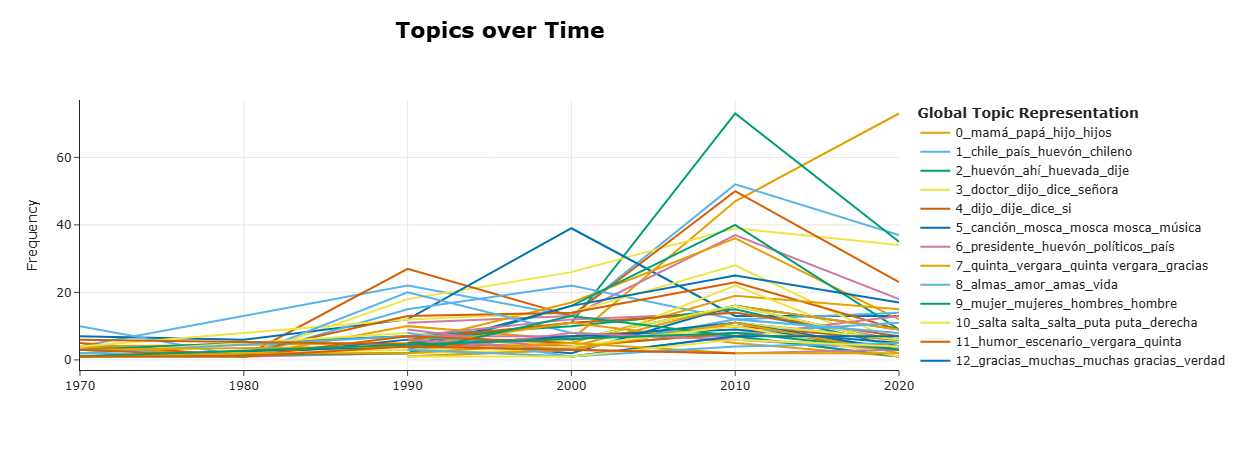

In [19]:
fig = topic_model.visualize_topics_over_time(topics_over_time)
fig.write_image("topics_over_decades.png")

display(Image(filename="topics_over_decades.png"))


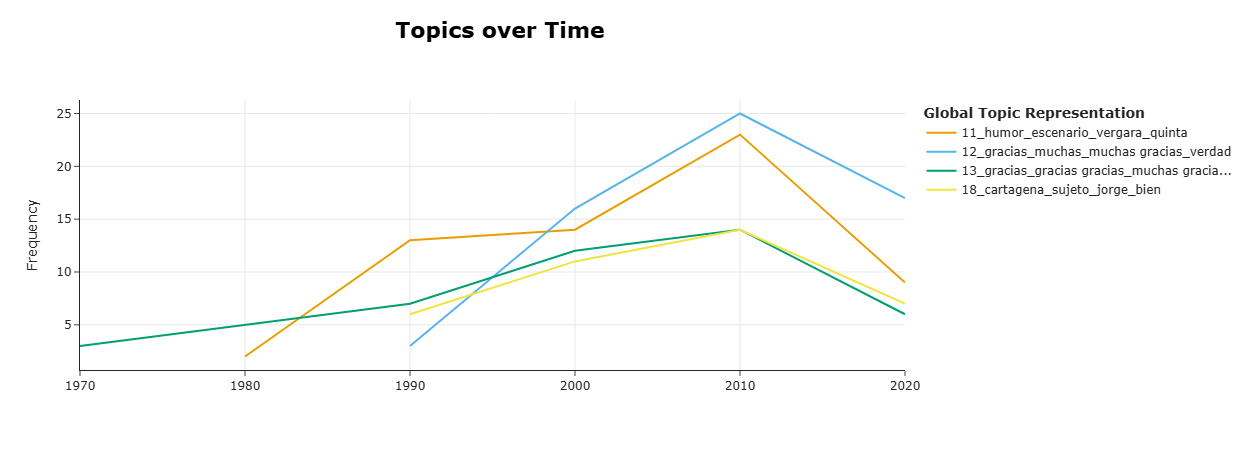

In [20]:
fig = topic_model.visualize_topics_over_time(topics_over_time, topics=[11, 12, 13, 18])
fig.write_image("selected_topics_over_decades.png")

display(Image(filename="selected_topics_over_decades.png"))